In [8]:
from simfile import SimFile
from simulation import Simulation
from validation import switchAllEffectsOff
import os
import matplotlib.pyplot as plt
import referenceFrames as rf
import numpy as np
import math
from scipy import optimize

In [9]:
def gaussian(height, center_x, center_y, width_x, width_y):
    """Returns a gaussian function with the given parameters"""
    width_x = float(width_x)
    width_y = float(width_y)
    return lambda x,y: height*np.exp(
                -(((center_x-x)/width_x)**2+((center_y-y)/width_y)**2)/2)

def moments(data):
    """Returns (height, x, y, width_x, width_y)
    the gaussian parameters of a 2D distribution by calculating its
    moments """
    total = data.sum()
    X, Y = np.indices(data.shape)
    x = (X*data).sum()/total
    y = (Y*data).sum()/total
    col = data[:, int(y)]
    width_x = np.sqrt(np.abs((np.arange(col.size)-y)**2*col).sum()/col.sum())
    row = data[int(x), :]
    width_y = np.sqrt(np.abs((np.arange(row.size)-x)**2*row).sum()/row.sum())
    height = data.max()
    return height, x, y, width_x, width_y

def fitgaussian(data):
    """Returns (height, x, y, width_x, width_y)
    the gaussian parameters of a 2D distribution found by a fit"""
    params = moments(data)
    errorfunction = lambda p: np.ravel(gaussian(*p)(*np.indices(data.shape)) -
                                 data)
    p, success = optimize.leastsq(errorfunction, params)
    return p

In [10]:
sim = Simulation("BFE")
switchAllEffectsOff(sim)
sim["ObservingParameters/NumExposures"] = 1
sim.outputDir = os.environ["PLATO_WORKDIR"]

sim["PSF/Model"] = "MappedGaussian"
sim["PSF/MappedGaussian/Sigma"]  = 20
sim["CCD/IncludeConvolution"] = "yes"
sim["CCD/IncludeBFE"] = "no"
sim["SubField/SubPixels"] = 16

In [11]:
starCatalogFilename = os.environ["PLATO_WORKDIR"] + "generatedFromPixelCoordinates.starcat"

dim = 20
numSubPixels = sim["SubField/SubPixels"]
dimSubPixels = dim * numSubPixels
Xin, Yin = np.mgrid[0:dimSubPixels, 0:dimSubPixels]

charges = np.arange(0, 1000000, 10000)

#magnitudes = 
magnitudes = np.arange(8, 20)
width = np.array([])

for magnitude in magnitudes:
    
    sim.createStarCatalogFileFromPixelCoordinates(np.array([100]), np.array([100]), np.array([12.5]), np.array([1]), starCatalogFilename)
    sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename

    sim["SubField/NumRows"] = dim
    sim["SubField/NumColumns"] = dim
    sim["SubField/ZeroPointRow"] = 100 - dim // 2
    sim["SubField/ZeroPointColumn"] = 100 - dim // 2
    

    sim["ControlHDF5Content/WriteSubPixelImages"] = "yes"
    output = sim.run(removeOutputFile = True)
    
    
    data = output.getSubPixelImage(0)

    params = fitgaussian(data)
    fit = gaussian(*params)
    width = np.append(width, params[3])
    print(params)



[ 29.95053195 158.83488802 158.83488407 134.58955784 134.58956691]


[ 29.95053195 158.83488802 158.83488407 134.58955784 134.58956691]


[ 29.95053195 158.83488802 158.83488407 134.58955784 134.58956691]


[ 29.95053195 158.83488802 158.83488407 134.58955784 134.58956691]


[ 29.95053195 158.83488802 158.83488407 134.58955784 134.58956691]


[ 29.95053195 158.83488802 158.83488407 134.58955784 134.58956691]


[ 29.95053195 158.83488802 158.83488407 134.58955784 134.58956691]


[ 29.95053195 158.83488802 158.83488407 134.58955784 134.58956691]


[ 29.95053195 158.83488802 158.83488407 134.58955784 134.58956691]


[ 29.95053195 158.83488802 158.83488407 134.58955784 134.58956691]


[ 29.95053195 158.83488802 158.83488407 134.58955784 134.58956691]


[ 29.95053195 158.83488802 158.83488407 134.58955784 134.58956691]


Text(0, 0.5, 'FWHM of PSF [pixels]')

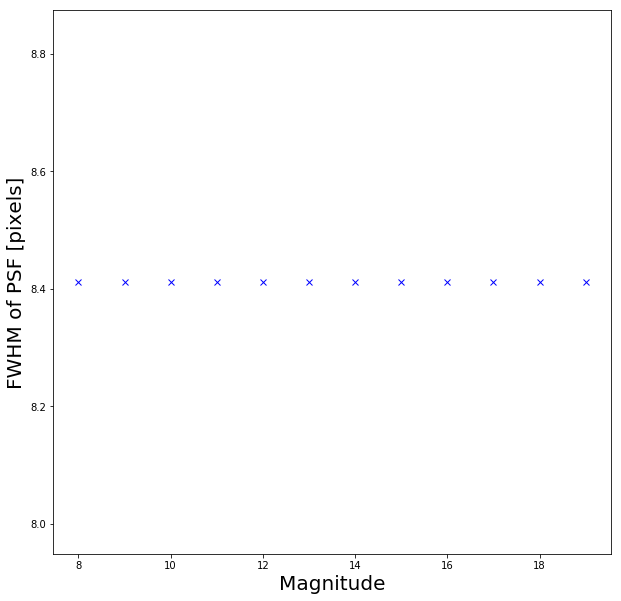

In [12]:
fig = plt.figure(figsize = (10, 10))
plt.plot(magnitudes, width / numSubPixels, "bx")

plt.xlabel("Magnitude", fontsize = 20)
plt.ylabel("FWHM of PSF [pixels]", fontsize = 20)

In [13]:
print(width)

[134.58955784 134.58955784 134.58955784 134.58955784 134.58955784
 134.58955784 134.58955784 134.58955784 134.58955784 134.58955784
 134.58955784 134.58955784]


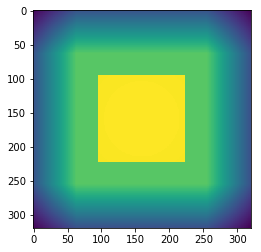

In [14]:
plt.imshow(output.getSubPixelImage(0))